In [1]:
%reload_ext autoreload
%autoreload 2
import math
import os
from pathlib import Path
import sys
from typing import Any, Literal, Optional

import numpy as np
from qecbench import TaskStats

# Add parent directory to the path
sys.path.insert(0, os.path.abspath(".."))

# Register learned decoders so they can be instantiated by `qecdec.decoders.create_decoder`.
import learned_decoders  # noqa: F401
from utils import get_csv_path

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import plot_utils

%matplotlib inline
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 12, "pdf.fonttype": 42})

In [3]:
LIST_NUM_RELAYS = [1, 2, 4, 8, 16]
LIST_NUM_CHAINS = [1, 2, 4, 8, 16]

# Helper functions

In [4]:
def _norm_val(v: Any) -> Any:
    """Normalize lists/tuples to tuples so JSON-loaded params compare equal.

    On load, ``TaskStats`` converts ``gamma_dist_interval`` to a tuple, while
    callers typically pass it as a list; normalizing both sides makes equality work.
    """
    return tuple(v) if isinstance(v, (list, tuple)) else v


def _params_match(decoder_params: Any, fixed_params: dict[str, Any]) -> bool:
    """True if ``decoder_params`` matches every key/value in ``fixed_params``."""
    return all(
        _norm_val(decoder_params.get(k)) == _norm_val(v)
        for k, v in fixed_params.items()
    )

In [5]:
def _build_fr_grid(
    stats: list[TaskStats],
    *,
    fixed_params: dict[str, Any],
    error_rate: float,
    all_num_chains: list[int],
    all_num_relays: list[int],
    fr_mode: Literal["per_shot", "per_round"],
    rounds: int,
) -> np.ndarray:
    """Failure-rate grid over (num_chains x num_relays); missing cells are NaN."""
    grid = np.full((len(all_num_chains), len(all_num_relays)), np.nan)
    for s in stats:
        m = s.metadata
        if not math.isclose(m.error_rate, error_rate):
            continue
        if not _params_match(m.decoder_params, fixed_params):
            continue
        nc = m.decoder_params.get("num_chains")
        nr = m.decoder_params.get("num_relays")
        if nc not in all_num_chains or nr not in all_num_relays:
            continue
        fr = s.failure_rate
        if fr_mode == "per_round":
            fr = plot_utils.shot_error_rate_to_piece_error_rate(fr, pieces=rounds)
        grid[all_num_chains.index(nc), all_num_relays.index(nr)] = fr
    return grid


def plot_fr_heatmap(
    *,
    circuit_name: str,
    circuit_params: dict[str, Any],
    multirelaybp_fixed_params: dict[str, Any],
    learned_multirelaybp_fixed_params: Optional[dict[str, Any]] = None,
    error_rates: list[float],
    all_num_relays: list[int],
    all_num_chains: list[int],
    fr_mode: Literal["per_shot", "per_round"],
    include_learned: bool = True,
    suptitle: Optional[str] = None,
    save_at: Optional[str | Path] = None,
):
    # upper row: MultiRelayBP
    # lower row: LearnedMultiRelayBP (only when `include_learned` is True)
    # column: one for each error rate
    # within each Axes: num_chains (rows) x num_relays (cols) failure-rate heatmap
    decoders: list[tuple[str, dict[str, Any]]] = [
        ("MultiRelayBP", multirelaybp_fixed_params),
    ]
    if include_learned:
        if learned_multirelaybp_fixed_params is None:
            raise ValueError(
                "learned_multirelaybp_fixed_params is required when include_learned=True"
            )
        decoders.append(("LearnedMultiRelayBP", learned_multirelaybp_fixed_params))
    rounds = circuit_params["rounds"]

    # Build all grids first so we can derive a single shared color norm.
    grids: dict[tuple[int, int], np.ndarray] = {}
    for r, (decoder_name, fixed_params) in enumerate(decoders):
        stats = TaskStats.load_csv(
            get_csv_path(circuit_name, circuit_params, decoder_name)
        )
        for c, p in enumerate(error_rates):
            grids[(r, c)] = _build_fr_grid(
                stats,
                fixed_params=fixed_params,
                error_rate=p,
                all_num_chains=all_num_chains,
                all_num_relays=all_num_relays,
                fr_mode=fr_mode,
                rounds=rounds,
            )

    # Shared LogNorm across the whole figure, built from finite positive values.
    finite_vals = np.concatenate([g[np.isfinite(g)].ravel() for g in grids.values()])
    positive = finite_vals[finite_vals > 0]
    if positive.size == 0:
        print("No data found for the requested parameters; nothing to plot.")
        return
    vmin, vmax = float(positive.min()), float(positive.max())
    if vmin == vmax:
        vmin, vmax = vmin / 2, vmax * 2
    norm = LogNorm(vmin=vmin, vmax=vmax)

    nrows, ncols = len(decoders), len(error_rates)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5 * ncols + 1, 5 * nrows), squeeze=False
    )

    fr_label = "Failure rate" if fr_mode == "per_shot" else "Failure rate per round"

    im = None
    for r, (decoder_name, _) in enumerate(decoders):
        for c, p in enumerate(error_rates):
            im = plot_utils.plot_heatmap(
                grids[(r, c)],
                axes[r][c],
                x_values=all_num_relays,
                y_values=all_num_chains,
                norm=norm,
                x_label="num_relays",
                y_label=("num_chains" if c == 0 else None),
                title=(f"p = {p:g}" if r == 0 else None),
            )
        # Decoder name as a row label to the left of the leftmost Axes.
        axes[r][0].annotate(
            decoder_name,
            xy=(0, 0.5),
            xytext=(-axes[r][0].yaxis.labelpad - 45, 0),
            xycoords=axes[r][0].yaxis.label,
            textcoords="offset points",
            ha="center",
            va="center",
            rotation=90,
            fontsize=plot_utils.LABEL_FONTSIZE,
            fontweight="bold",
        )

    fig.colorbar(im, ax=axes.ravel().tolist(), label=fr_label, fraction=0.046, pad=0.02)

    if suptitle:
        fig.suptitle(suptitle, fontsize=plot_utils.SUPTITLE_FONTSIZE)
    if save_at:
        fig.savefig(save_at, bbox_inches="tight")
    plt.show()

# RotatedSurfaceCode_Circuit, basis=Z, d=11, rounds=11

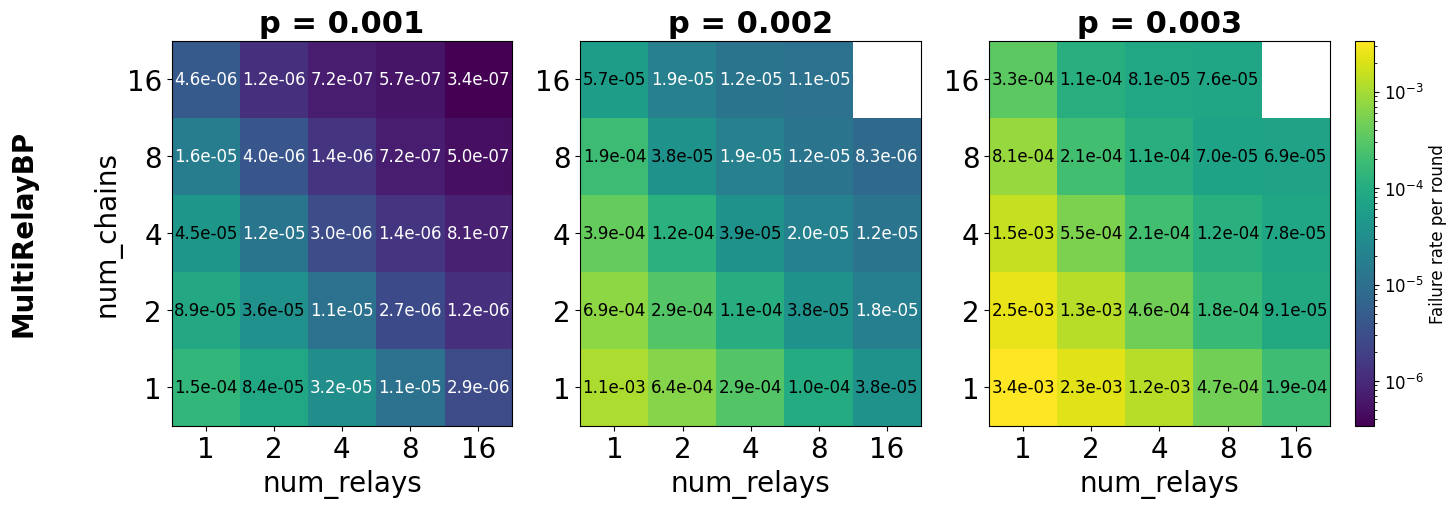

In [12]:
circuit_name = "RotatedSurfaceCode_Circuit"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}
error_rates = [0.001, 0.002, 0.003]

multirelaybp_fixed_params = {
    "gamma0": 0.55,
    "gamma_dist_interval": (-0.2944735403909491, 0.9444054073490704),
    "max_iter_per_relay": 50,
    "pre_iter": 50,
    "stop_nconv": 1,
}

plot_fr_heatmap(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    multirelaybp_fixed_params=multirelaybp_fixed_params,
    error_rates=error_rates,
    all_num_relays=LIST_NUM_RELAYS,
    all_num_chains=LIST_NUM_CHAINS,
    fr_mode="per_round",
    include_learned=False,
)

# RotatedSurfaceCode_Phenom, basis=Z, d=11, rounds=11

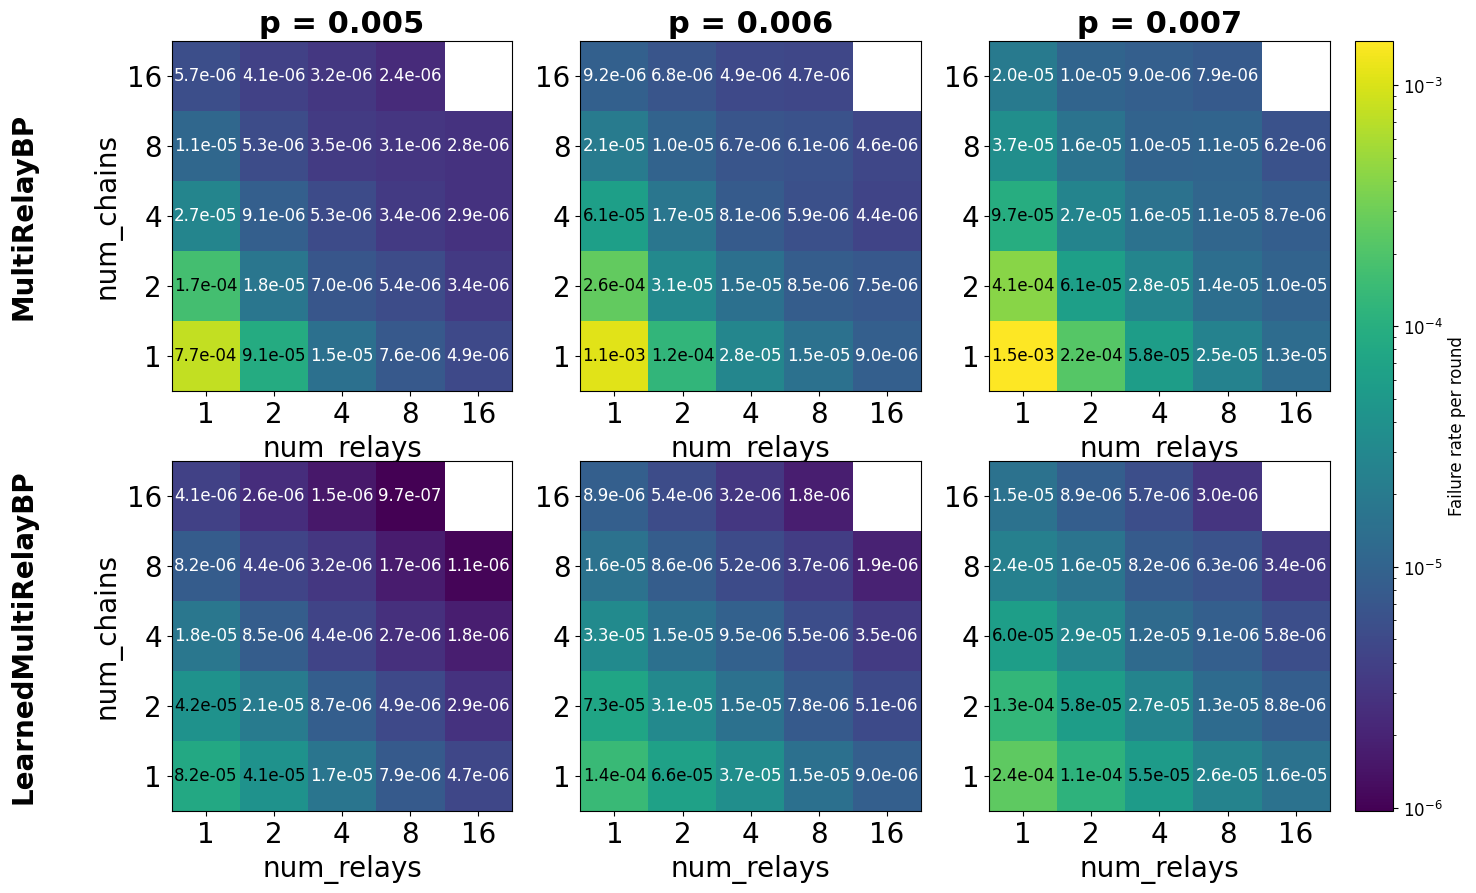

In [13]:
circuit_name = "RotatedSurfaceCode_Phenom"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}
error_rates = [0.005, 0.006, 0.007]

common_params = {
    "gamma_dist_interval": (-0.2241259276391633, 0.5608805426310253),
    "max_iter_per_relay": 50,
    "pre_iter": 50,
    "stop_nconv": 1,
}
multirelaybp_fixed_params = {"gamma0": 0.65, **common_params}
learned_multirelaybp_fixed_params = {
    "ckpt_rel_path": "torchdecoder/runs/RotatedSurfaceCode_Phenom/basis=Z_d=11_rounds=11/LearnedDMemBP/run_0/checkpoints/best_model.ckpt",
    **common_params,
}

plot_fr_heatmap(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    multirelaybp_fixed_params=multirelaybp_fixed_params,
    learned_multirelaybp_fixed_params=learned_multirelaybp_fixed_params,
    error_rates=error_rates,
    all_num_relays=LIST_NUM_RELAYS,
    all_num_chains=LIST_NUM_CHAINS,
    fr_mode="per_round",
)

# BB_144_12_12_Circuit, basis=Z, rounds=12

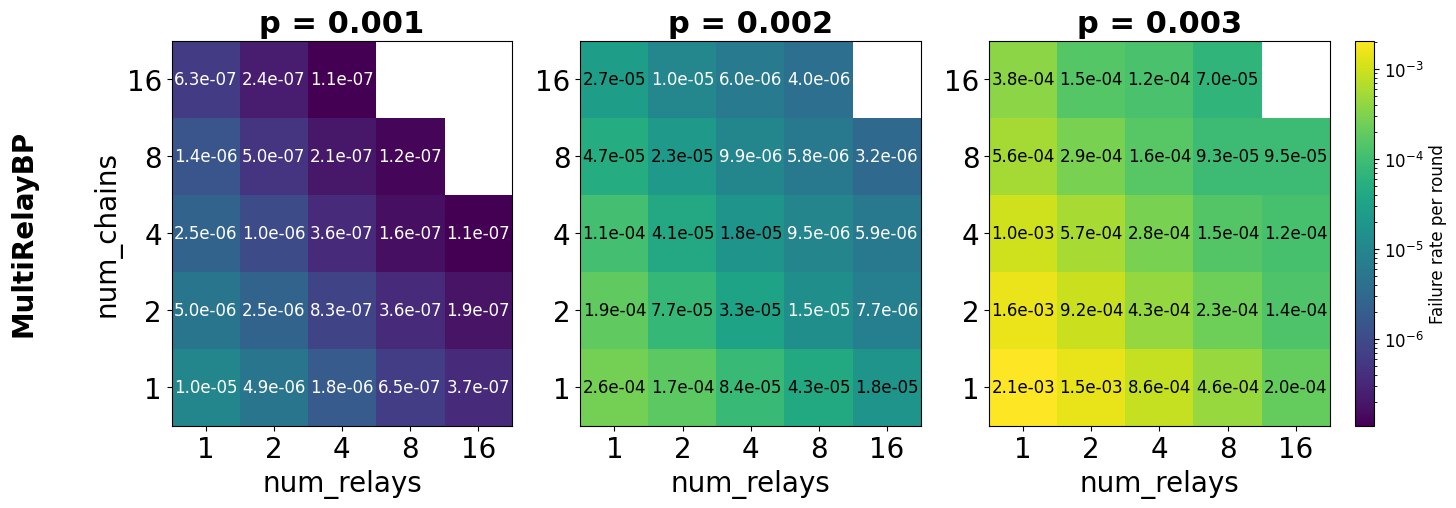

In [14]:
circuit_name = "BB_144_12_12_Circuit"
circuit_params = {"basis": "Z", "rounds": 12}
error_rates = [0.001, 0.002, 0.003]

multirelaybp_fixed_params = {
    "gamma0": 0.2,
    "gamma_dist_interval": (-0.19806670996164882, 0.6200937872049607),
    "max_iter_per_relay": 50,
    "pre_iter": 50,
    "stop_nconv": 1,
}

plot_fr_heatmap(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    multirelaybp_fixed_params=multirelaybp_fixed_params,
    error_rates=error_rates,
    all_num_relays=LIST_NUM_RELAYS,
    all_num_chains=LIST_NUM_CHAINS,
    fr_mode="per_round",
    include_learned=False,
)